# Get started with Earth Engine for Python

In [ ]:
#@title Copyright 2024 The Earth Engine Community Authors { display-mode: "form" }
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

This quickstart will give you an interactive introduction to visualizing and
analyzing geospatial data with the Earth Engine Python interface.

## Before you begin

[Register or create](https://code.earthengine.google.com/register) a Google Cloud Project; you'll be prompted to complete the following steps. If you already have a project registered for Earth Engine access, skip to the next section.

  * Select the project's purpose: commercial or noncommercial.
  * If the purpose is noncommercial, select a project type.
  * Create a new Google Cloud project or select an existing project.
  * If the purpose is commercial, verify or set up billing for your project.
  * Confirm your project information.  

**Note:** If you don't plan to keep the resources that you create in this procedure, create a project instead of selecting an existing project. After you finish these steps, you can [delete the project](https://cloud.google.com/resource-manager/docs/creating-managing-projects#shutting_down_projects), removing all resources owned by the project.

## Notebook setup

**1.** Import the Earth Engine and geemap libraries.

In [17]:
import ee
import geemap.core as geemap

**2.** Authenticate and initialize the Earth Engine service. Follow the
resulting prompts to complete authentication. Be sure to replace PROJECT_ID
with the name of the project you set up for this quickstart.

In [19]:
ee.Authenticate()
ee.Initialize(project='riftwaters')

In [ ]:
import geemap

m = geemap.Map(center=[0.29, 36.09], zoom=10)
image = "/home/desy/rift-waters/dataset/bogoria/raw/landsat8/landsat8_2025-01-01_to_2025-01-31.tif"

# vis_params = {
#             "bands": ["b4", "b3", "b2"],  # RGB bands for Landsat 8
#             "min": 0.0,
#             "max": 0.3,
#         }

# m.add_layer(image, vis_params)
#     # Display the map
# m

rgb_img = geemap.ee_to_numpy(image)
print(rgb_img.shape)

EEException: Expression does not evaluate to an image.

In [27]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

#img = ee.Image("LANDSAT/LC08/C02/T1_L2").select(["B4", "B5", "B6"])



aoi = ee.Geometry.Polygon(
    [
        [
            [36.021644575238554, 0.15353594768753728],
            [36.18025968754324, 0.15353594768753728],
            [36.18025968754324, 0.36364721537653627],
            [36.021644575238554, 0.36364721537653627],
            [36.021644575238554, 0.15353594768753728],
        ]
    ],
    None,
    False,
)


img = (
                ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                .filterBounds(aoi)
                .filterDate('2023-01', '2023-02')
                .filter(ee.Filter.lt("CLOUD_COVER", 0))
            )




rgb_img = geemap.ee_to_numpy(img)
print(rgb_img.shape)

EEException: Expression does not evaluate to an image.

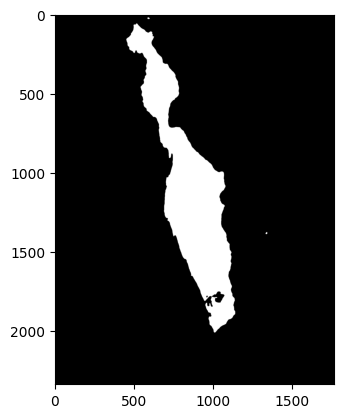

In [3]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open('/home/desy/rift-waters/water_mask_detected.tif') as src:
    image = src.read(1)
    plt.imshow(image, cmap='gray')
    plt.show()

In [ ]:
rgb_img = geemap.ee_to_numpy(img, region=aoi)
print(rgb_img.shape)

In [9]:
import numpy as np
import rasterio

# Read raster bands directly to Numpy arrays.
#
with rasterio.open('dataset/bogoria/raw/landsat8/landsat8_2025-01-01_to_2025-01-31.tif') as src:
    red = src.read(3).astype(float)
    green = src.read(2).astype(float)
    blue = src.read(1).astype(float)
    nir = src.read(4).astype(float)
    swir1 = src.read(5).astype(float)

# Combine arrays in place. Expecting that the sum will
# temporarily exceed the 8-bit integer range, initialize it as
# a 64-bit float (the numpy default) array. Adding other
# arrays to it in-place converts those arrays "up" and
# preserves the type of the total array.
total = np.zeros(src.shape)

for band in red, green, blue:
    total += band

total /= 3

# Write the product as a raster band to a new 8-bit file. For
# the new file's profile, we start with the meta attributes of
# the source file, but then change the band count to 1, set the
# dtype to uint8, and specify LZW compression.
profile = src.profile
profile.update(dtype=rasterio.uint8, count=1, compress='lzw')

with rasterio.open('dataset/bogoria/raw/landsat8/landsat8_2025-01-01_to_2025-01-31.tif', 'w', **profile) as dst:
    dst.write(total.astype(rasterio.uint8), 1)

RasterioIOError: Dataset is closed: dataset/bogoria/raw/landsat8/landsat8_2025-01-01_to_2025-01-31.tif

## Add raster data to a map

**1.** Load climate data for a given period and display its metadata.

In [3]:
jan_2023_climate = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate('2023-01', '2023-02')
    .first()
)
jan_2023_climate

**2.** Instantiate a map object and add the temperature band as a layer with
specific visualization properties. Display the map.

In [4]:
m = geemap.Map(center=[30, 0], zoom=2)

vis_params = {
    'bands': ['temperature_2m'],
    'min': 229,
    'max': 304,
    'palette': 'inferno',
}
m.add_layer(jan_2023_climate, vis_params, 'Temperature (K)')
m

Map(center=[30, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', trans…

## Add vector data to a map

**1.** Create a vector data object with points for three cities.

In [5]:
cities = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point(10.75, 59.91), {'city': 'Oslo'}),
    ee.Feature(ee.Geometry.Point(-118.24, 34.05), {'city': 'Los Angeles'}),
    ee.Feature(ee.Geometry.Point(103.83, 1.33), {'city': 'Singapore'}),
])
cities

**2.** Add the city locations to the map and redisplay it.

In [9]:
m.add_layer(cities, name='Cities')
m

Map(center=[30, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', trans…

## Extract and chart data

**1.** Import the Altair charting library.

In [10]:
%pip install -q --upgrade altair
import altair as alt

Note: you may need to restart the kernel to use updated packages.


**2.** Extract the climate data for the three cities as a pandas DataFrame.

In [11]:
city_climates = jan_2023_climate.reduceRegions(cities, ee.Reducer.first())

city_climates_dataframe = ee.data.computeFeatures(
    {'expression': city_climates, 'fileFormat': 'PANDAS_DATAFRAME'}
)
city_climates_dataframe

,geo,city,dewpoint_temperature_2m,dewpoint_temperature_2m_max,dewpoint_temperature_2m_min,evaporation_from_bare_soil_max,evaporation_from_bare_soil_min,evaporation_from_bare_soil_sum,evaporation_from_open_water_surfaces_excluding_oceans_max,evaporation_from_open_water_surfaces_excluding_oceans_min,...,volumetric_soil_water_layer_1_min,volumetric_soil_water_layer_2,volumetric_soil_water_layer_2_max,volumetric_soil_water_layer_2_min,volumetric_soil_water_layer_3,volumetric_soil_water_layer_3_max,volumetric_soil_water_layer_3_min,volumetric_soil_water_layer_4,volumetric_soil_water_layer_4_max,volumetric_soil_water_layer_4_min
0,"{'type': 'Point', 'coordinates': [10.75, 59.91]}",Oslo,268.522069,277.052826,255.988235,2.328306e-10,-0.000028,-0.000109,6.047194e-07,-2.328306e-10,...,0.240875,0.277464,0.339737,0.242050,0.288395,0.312698,0.263550,0.283256,0.291718,0.269760
1,"{'type': 'Point', 'coordinates': [-118.24, 34....",Los Angeles,279.018688,286.388687,265.190689,2.328306e-10,-0.000191,-0.016581,1.587765e-05,-2.093231e-04,...,0.293442,0.378105,0.438995,0.267899,0.338553,0.410660,0.196136,0.217798,0.233704,0.208649
2,"{'type': 'Point', 'coordinates': [103.83, 1.33]}",Singapore,296.269420,298.315628,294.220779,0.000000e+00,-0.000365,-0.036704,1.164153e-10,-1.259167e-04,...,0.393356,0.436111,0.520004,0.405411,0.436325,0.519806,0.401047,0.496528,0.510345,0.489883


**3.** Plot the temperature for the cities as a bar chart.

In [12]:
alt.Chart(city_climates_dataframe).mark_bar(size=100).encode(
    alt.X('city:N', sort='y', axis=alt.Axis(labelAngle=0), title='City'),
    alt.Y('temperature_2m:Q', title='Temperature (K)'),
    tooltip=[
        alt.Tooltip('city:N', title='City'),
        alt.Tooltip('temperature_2m:Q', title='Temperature (K)'),
    ],
).properties(title='January 2023 temperature for selected cities', width=500)

alt.Chart(...)

## What's next

  * Learn about analyzing data with Earth Engine's [objects and methods](https://developers.google.com/earth-engine/guides/objects_methods_overview).
  * Learn about Earth Engine's [processing environments](https://developers.google.com/earth-engine/guides/processing_environments).
  * Learn about Earth Engine's [machine learning capabilities](https://developers.google.com/earth-engine/guides/machine-learning).
  * Learn how to [export your computation results to BigQuery](https://developers.google.com/earth-engine/guides/exporting_to_bigquery).